# 6. The controls

This notebook collects the numerical controls of the project: which parameter was varied, what it
was compared against, and what the comparison gave.

The first control is run here, so that the pattern is visible. The rest read the cached results in
`data/local/` through the analysis scripts that produced the numbers in the thesis, so the notebook
runs in a few minutes. Each script is named where it is used, and `scripts/README.md` lists them
all.

| control | question | script |
|---|---|---|
| RTM vs RDM | does the truncation scheme change the answer? | `fig_conv.jl`, `battery_report.jl` |
| seed ensembles | how often does the iteration fail, and how spread are the survivors? | `battery_report.jl` |
| cutoff scan | does the SVD cutoff move the eigenvalues? | `battery_report.jl` |
| dense diagnostics | what does the exact dense operator give at small T? | `battery_report.jl` |
| Trotter step | does δt = 0.05 change anything but the cost? | `dtreport.jl` |
| bond dimension | χ = 64 against χ = 128 | `chi_check.jl` |
| warm vs cold starts | does warm-starting bias the answer? | `warmcold.jl` |
| eigensolver modes | do the :eig and :schur modes agree? | `mode_agreement.jl` |
| cost of compression | does capping the partial sums save time? | `costcheck.jl` |
| fit windows | how sensitive is c to the fitting window? | `eq3_windows.jl` |
| entropy fit models | which plateau extrapolation, and why? | `entropy_c.jl` |
| spectral seed statistics | does the block route fail near the window edge? | `analysis_pack.jl` |

The producer scripts recompute only if their cache has been deleted; otherwise they go straight to
the tables.

In [1]:
# load the library: model Hamiltonians, the temporal-MPO construction, the block power
# method, the entropy routines, and the plotting theme
include("../src/thesislib.jl")
using JLD2, Printf, Statistics
thesis_plot_theme!()

## The bond dimension

The truncation is capped by a bond dimension. If that cap were setting the answer, changing it would
move the result. Below we run the same rung twice, capping at 16 and at 48, and compare the leading
eigenvalue and the entropy plateau.

In [2]:
# same rung, same settings, only the bond-dimension cap differs
@printf("%-6s %-18s %-16s %s\n", "cap", "|mu0|", "plateau Im S2", "chi actually reached")
for chi in (16, 48)
    r  = run_pm_diagnosed(3.0; p=0.0, dt=0.1, nbeta=4, maxdim=chi, column=:bulk5)
    s2 = collect(ITransverse.gen_renyi2(r.L, r.R))
    @printf("%-6d %-18.10f %-16.5f %d\n", chi, abs(r.lambda0), plateau_im(s2, 4), maxlinkdim(r.R))
end

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[PM LR|RTM] L=34, cutoff=1.0e-14, maxdim=48, normalize=overlap)   2%  ETA: 0:00:16 ( 3.25 ms/it)
   Info: [94]  chi=6 | ds=1.1852090021635675e-5 | <R|Rprev> = NaN

48     1.4922460225       0.13170          6


[ Info: PM Converged after 119 steps | ds=8.509602112960479e-7 | chi=6)


The two agree to nine digits in the eigenvalue and exactly in the plateau, and the converged state
reaches a bond dimension of 6 in both cases, so the cap is never touched at this rung. Its purpose
is to prevent transient growth during the iteration from exhausting memory, not to determine the
fixed point.

The full grid below compares the production cap of 64 against 128 on the ladders that have both, for
the plateau and for the slope of the real part.

## RTM against RDM

Same rung, same seed, with only the truncation scheme changed. RTM levels off above the tolerance
and stops on the no-improvement rule, while RDM crosses it. The two eigenvalues agree to
$1.9\times10^{-6}$, so the floor costs iterations rather than accuracy.

rdm: converged, 705 iters, final ds 7.85e-07, min 7.85e-07, lambda0 -1.3631832572+0.5911505226im
rtm: stuck, 1266 iters, final ds 9.79e-04, min 2.25e-04, lambda0 -1.3631945753+0.5912328580im


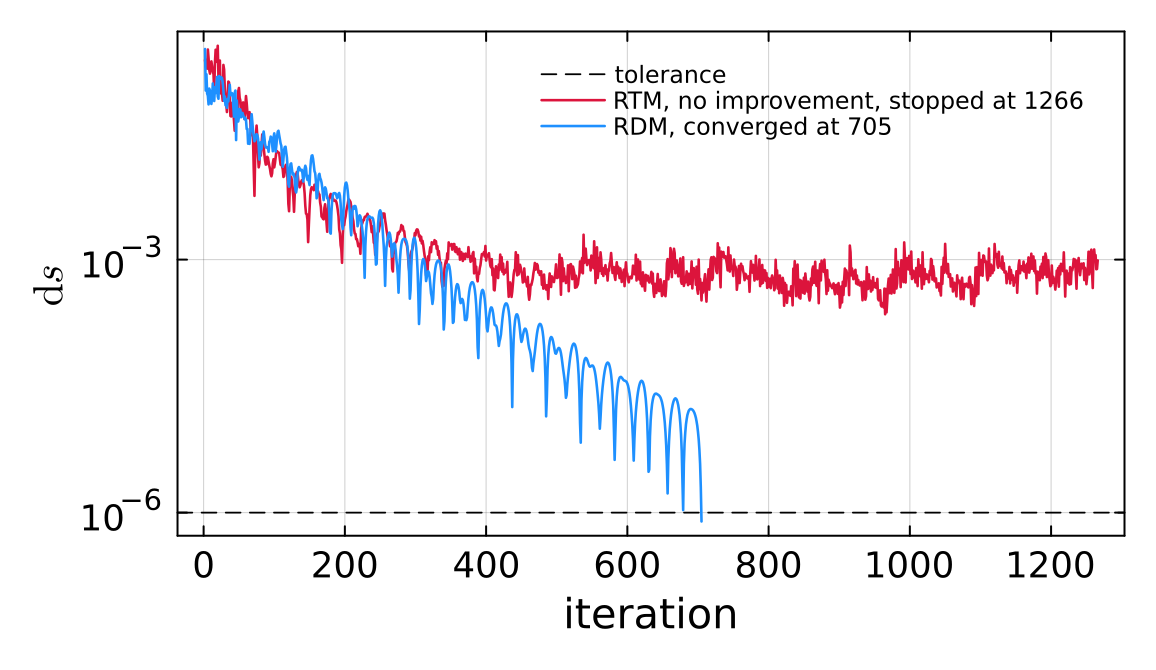

In [3]:
include("../scripts/figures/fig_conv.jl")
make_conv()

## Seed ensembles, cutoff and dense diagnostics

Every production rung repeated from independent random seeds, where the spread of the surviving runs
is the uncertainty of the method; the SVD-cutoff scan; and the exact diagnostics on the corrected
column at small $T$. Passing `detail` to the script prints the per-seed listing.

In [4]:
# recomputes the seed ensembles, the cutoff scan and the dense diagnostics
# from data/local/controls/ — pass `detail` for the per-seed listing
include("../scripts/analysis/battery_report.jl")

=== seed ensembles (single-vector route) ===
cache                      n    fail loose  fail tight  med(good)   spread     rigidity
seedens_chi128_p0.1_T14.0.jld2 2    1/2         1/2         0.1238     2.03e-01   1.27e-10


seedens_chi128_p0.3_T10.0.jld2 4    2/4         3/4         0.1213     1.40e-01   8.74e-09
seedens_chi128_p0.3_T9.0.jld2 6    3/6         3/6         0.0830     8.10e-02   6.81e-08
seedens_chi128_p0.5_T5.0.jld2 8    6/8         6/8         0.1318     1.97e-01   1.52e-05
seedens_chi128_p0.5_T6.0.jld2 3    3/3         3/3            --      1.23e-01   1.94e-06
seedens_dt005_p0.0_T18.0.jld2 20   1/20        1/20        0.1147     8.23e-03   1.03e-05
seedens_dt005_p0.0_T22.0.jld2 20   2/20        3/20        0.1043     2.86e-02   7.84e-07
seedens_dt005_p0.0_T24.0.jld2 20   6/20        10/20       0.0975     6.46e-02   2.12e-07
seedens_dt005_p0.1_T11.0.jld2 10   0/10        0/10        0.0970     7.15e-03   1.44e-08
seedens_dt005_p0.1_T12.0.jld2 10   2/10        5/10        0.0793     6.38e-02   2.68e-09
seedens_dt005_p0.3_T8.0.jld2 10   1/10        3/10        0.1372     2.75e-02   4.13e-07
seedens_dt005_p0.3_T9.0.jld2 10   4/10        6/10        0.1068     9.75e-02   6.03e-08
seedens_p0.

seedens_p0.0_T20.0.jld2    20   0/20        1/20        0.1146     1.01e-02   2.62e-06
seedens_p0.0_T22.0.jld2    20   2/20        2/20        0.1080     2.17e-02   7.17e-07
seedens_p0.0_T24.0.jld2    20   4/20        6/20        0.1205     4.06e-02   1.96e-07
seedens_p0.0_T3.0.jld2     20   0/20        0/20        0.1316     7.21e-06   1.54e-01
seedens_p0.0_T4.0.jld2     20   0/20        0/20        0.1318     8.84e-06   8.05e-02
seedens_p0.0_T5.0.jld2     20   0/20        0/20        0.1298     2.02e-10   4.22e-02
seedens_p0.0_T6.0.jld2     20   0/20        0/20        0.1273     2.05e-05   2.21e-02
seedens_p0.0_T7.0.jld2     20   0/20        0/20        0.1274     1.48e-05   1.16e-02
seedens_p0.0_T8.0.jld2     20   0/20        0/20        0.1252     2.20e-05   6.08e-03
seedens_p0.1_T10.0.jld2    10   0/10        0/10        0.1204     6.45e-03   1.04e-07
seedens_p0.1_T11.0.jld2    10   2/10        2/10        0.1199     1.15e-02   2.04e-08
seedens_p0.1_T12.0.jld2    10   0/10       

p     T     dim    |mu0|    |mu1/mu0|  gap01      rigidity   cond(V)    supp(trunc)
0.0   1.5   27     0.9048   0.92545    4.044e-01  4.327e-01  9.655e+00  1.08e-01


0.0   2.0   81     0.9129   0.95321    3.197e-01  3.145e-01  2.831e+01  3.62e-02
0.0   2.5   243    0.9153   0.96893    2.670e-01  2.291e-01  5.008e+01  1.04e-02
0.0   3.0   729    0.9173   0.97686    2.312e-01  1.640e-01  1.077e+02  2.35e-02
0.0   3.5   2187   0.9225   0.98257    2.053e-01  1.190e-01  2.991e+02  8.49e-03
0.1   1.0   169    0.9304   0.92539    4.561e-01  3.301e-01  1.914e+09  2.23e-02
0.1   1.5   2197   0.9405   0.96568    2.996e-01  1.625e-01  2.210e+11  1.05e-04
0.3   1.0   169    1.0347   0.96923    2.969e-01  3.377e-01  6.968e+08  4.53e-02
0.3   1.5   2197   1.1145   0.97494    1.853e-01  1.696e-01  2.089e+10  2.28e-02
0.5   1.0   169    1.2137   0.95528    2.023e-01  3.582e-01  2.079e+08  2.28e-02
0.5   1.5   2197   1.4391   0.96632    1.354e-01  1.949e-01  9.577e+09  1.14e-02

=== cutoff scan (block route, seeded) ===


p          T     cutoff    seed  niters  reason      time_s   g         plateau
0.0(fixed) 3.0   1e-12     1     17      converged   13       0.22814   0.0309


0.0(fixed) 3.0   1e-12     2     21      converged   18       0.22814   0.0309
0.0(fixed) 3.0   1e-12     3     18      converged   11       0.22814   0.0309
0.0(fixed) 3.0   1e-10     1     19      converged   14       0.22815   0.0306
0.0(fixed) 3.0   1e-10     2     25      converged   16       0.22815   0.0306
0.0(fixed) 3.0   1e-10     3     18      converged   11       0.22815   0.0306
0.0(fixed) 3.0   1e-08     1     51      converged   22       0.22815   0.0306
0.0(fixed) 3.0   1e-08     2     37      converged   19       0.22800   0.0244
0.0(fixed) 3.0   1e-08     3     51      converged   17       0.22815   0.0306
0.3        3.0   1e-12     1     48      converged   200      0.01406   0.1336
0.3        3.0   1e-12     2     67      converged   369      0.01406   0.1336
0.3        3.0   1e-12     3     55      converged   206      0.01406   0.1336
0.3        3.0   1e-10     1     57      converged   176      0.01406   0.1339
0.3        3.0   1e-10     2     221     stuck      

false

## The Trotter step

The same seed ensembles at $\delta t = 0.05$ against the $\delta t = 0.1$ baseline, together with
the three-step Trotter series of the plateau. The window does not move and the observables change
very little, so the production step is converged and the finer step only doubles the length of the
temporal chain.

In [5]:
# compares the dt=0.05 ensembles against the dt=0.1 baseline, and the
# three-step Trotter series of the plateau
include("../scripts/analysis/dtreport.jl")

=== failure rate: dt=0.05 vs dt=0.1 baseline ===
p      T     dt=0.1         dt=0.05        med(good) dt=0.05
0.0    18    1/20           1/20           0.1147


0.0    22    2/20           2/20           0.1043
0.0    24    4/20           6/20           0.0975
0.1    11    2/10           0/10           0.0970
0.1    12    0/10           2/10           0.0793
0.3    8     4/10           1/10           0.1372
0.3    9     6/10           4/10           0.1068

=== plateau vs dt (Richardson check; dt=0.1 / 0.05 from earlier ladders) ===
p=0.0 T=12    dt=0.025: plateau=0.1154  (stuck@734, 144s)


## Bond dimension: χ = 64 against χ = 128

Both estimators (plateau and Re-slope), both couplings that have the doubled-χ ladders.

In [6]:
# plateau and Re-slope at chi=64 against chi=128, both couplings that have
# the doubled ladders
include("../scripts/analysis/chi_check.jl")


p=0  shared T: 

[8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0]
    T plat 64    plat 128   d%          c_Re 64    c_Re 128   diff     
    8 0.1252     0.1251     0.06        0.689      0.688      0.001    


   10 0.1213     0.1208     0.45        0.656      0.629      0.027    
   12 0.1183     0.1193     0.88        0.649      0.622      0.026    
   14 0.1202     0.1165     3.03        0.585      0.648      0.063    
   16 0.1173     0.1149     2.03        0.700      0.628      0.072    
   18 0.1117     0.1102     1.38        0.569      0.685      0.116    
   20 0.1162     0.1185     2.01        0.490      0.382      0.108    

p=0.1  shared T: [10.0, 11.0, 12.0]
    T plat 64    plat 128   d%          c_Re 64    c_Re 128   diff     
   10 0.1134     0.0228     79.89       0.668      -1.834     2.502    
   11 0.1257     0.1184     5.79        0.618      0.537      0.080    
   12 0.1521     0.1447     4.81        1.005      0.621      0.384    


## Block size

The gap is a physical quantity, so it must not depend on how many states the block carries. Running
the same ladder with six states instead of four reproduces the four-state result to about
$10^{-5}$, except at three points where the two differ by a few per cent.

Those three points are where the $k = 4$ ladder in notebook 3 is irregular. A four-state block cuts
through the tower there instead of resolving it, which is why that panel is used only as a
qualitative map and no number in the thesis is taken from it.

In [7]:
# gap from a spectrum: lambda0 and its +/- partner are the two largest moduli, the gap is the next
function gap_of(theta)
    order = sortperm(abs.(theta), rev=true)
    rest = order[3:end]
    return isempty(rest) ? 0.0 : maximum(abs.(theta[rest])) / abs(theta[order[1]])
end

k4 = load("../data/local/nb55_pgap.jld2", "D")
k6 = load("../data/local/nb3_gap_k6.jld2", "done")

@printf("%-5s %-4s %-10s %-10s %-9s\n", "p", "T", "gap k=4", "gap k=6", "diff")
for key in sort([k for k in keys(k6) if k[1] == :k6], by = k -> (k[2], k[3]))
    p, T = key[2], key[3]
    g4, g6 = k4[p][T].gap, gap_of(k6[key].theta)
    @printf("%-5.1f %-4.0f %-10.4f %-10.4f %-9.1e\n", p, T, g4, g6, abs(g4 - g6))
end

p     T    gap k=4    gap k=6    diff     
0.0   2    0.6699     0.6699     4.6e-05  


0.0   3    0.8393     0.8393     2.9e-06  
0.0   4    0.9074     0.9074     5.0e-06  
0.0   5    0.9401     0.9401     4.2e-05  
0.0   6    0.9581     0.9581     6.5e-05  
0.0   7    0.9690     0.9690     4.4e-06  
0.1   2    0.7291     0.7292     2.9e-05  
0.1   3    0.8924     0.8924     1.2e-05  
0.1   4    0.9456     0.9456     1.7e-06  
0.1   5    0.9678     0.9678     7.6e-06  
0.1   6    0.9799     0.9787     1.2e-03  
0.3   2    0.8112     0.8113     6.0e-05  
0.3   3    0.9909     0.9514     3.9e-02  
0.3   4    0.8547     0.9482     9.4e-02  
0.5   2    0.8343     0.8343     8.8e-06  
0.5   3    0.8696     0.8696     1.4e-06  
0.5   4    0.9935     0.9002     9.3e-02  


## Warm against cold starts

The production ladders warm-start each rung from the previous block. Below we test whether that
biases the result: same rungs, same settings, same seed, with only the initialisation changed.

In [8]:
# the same rungs from a warm start and from a cold one, seed held fixed
include("../scripts/analysis/warmcold.jl")


=== warm versus cold at the same rungs ===


    T  cold (iters, s)        warm (iters, s)        d|mu0| relative
    3  68, 57                 68, 51                 0.00e+00
    4  234, 332               352, 471               6.82e-06
    5  409, 911               405, 851               6.77e-06
    6  352, 1249              416, 1494              1.16e-05


## The two eigensolver modes

Two independent warm-started ladders at $p = 0.1$ on the corrected column, one per mode. `:eig`
de-mixes and returns eigenvectors, `:schur` returns eigenvalues only. They are compared on the
Ritz-value ratios.

In [9]:
# two warm-started ladders at p=0.1, :eig against :schur, on the Ritz ratios
include("../scripts/analysis/mode_agreement.jl")


=== agreement of Ritz-value ratios between the two modes ===


   T  d|th1/th0|   d|th2/th0|   d|th3/th0|  
   2  8.50e-06     8.96e-04     3.38e-04    
   3  2.58e-06     1.96e-04     4.20e-03    
   4  2.76e-05     1.18e-02     6.28e-05    
   5  1.89e-06     3.64e-03     6.34e-04    
   6  4.92e-06     8.16e-05     1.01e-03    
   7  7.69e-08     1.39e-06     1.71e-03    
   8  1.72e-04     5.21e-04     2.47e-04    


## The cost of compressing the partial sums

The block update accumulates $k$ MPS, and `accdim` caps the running direct sum. Below we measure the
capped against the uncapped version at the same rungs, comparing wall time and the effect on
$|\mu_0|$.

In [10]:
# capped against uncapped partial sums: wall time, and the effect on |mu0|
include("../scripts/analysis/costcheck.jl")


=== compressing the partial sums: cost and effect on the answer ===


T=4  capped 234 its 316 s | plain 234 its 311 s | ratio 0.98 | d|mu0| 0.0e+00 relative
T=5  capped 262 its 635 s | plain 264 its 638 s | ratio 1.01 | d|mu0| 5.7e-07 relative


## Window sensitivity of the Eq. (3) fits

The spectral $c$ per coupling under every reasonable fit window, on the same ladders the
thesis quotes, plus the free-against-pinned branch constant.

In [11]:
# the spectral c under every reasonable Eq. (3) window, and the branch
# constant free against pinned
include("../scripts/analysis/eq3_windows.jl")

p=0.0  ladder T=2.0..20.0 (31 pts)


  T>=2 (31 pts) | pinned c=0.4512 rms=4.0e-05 | free B/pi=-1.0004 c=0.4140
  T>=3 (29 pts) | pinned c=0.4706 rms=1.0e-05 | free B/pi=-1.0001 c=0.4544


  T>=4 (27 pts) | pinned c=0.4758 rms=7.8e-06 | free B/pi=-1.0001 c=0.4650
  window sensitivity of pinned c: spread 0.025
p=0.1  ladder T=2.0..10.5 (17 pts)
  T>=2 (17 pts) | pinned c=0.4670 rms=2.5e-05 | free B/pi=-1.0003 c=0.4294
  T>=3 (15 pts) | pinned c=0.4812 rms=9.6e-06 | free B/pi=-1.0002 c=0.4452
  T>=4 (13 pts) | pinned c=0.4889 rms=7.1e-06 | free B/pi=-1.0003 c=0.4403
  window sensitivity of pinned c: spread 0.022
p=0.3  ladder T=2.0..7.5 (12 pts)
  T>=2 (12 pts) | pinned c=0.4979 rms=3.8e-05 | free B/pi=-1.0004 c=0.4444
  T>=3 (10 pts) | pinned c=0.5151 rms=3.7e-05 | free B/pi=-1.0006 c=0.3873
  T>=4 ( 8 pts) | pinned c=0.5354 rms=4.0e-05 | free B/pi=-1.0017 c=0.1250
  window sensitivity of pinned c: spread 0.038
p=0.5  ladder T=2.0..6.0 (9 pts)
  T>=2 ( 9 pts) | pinned c=0.5332 rms=5.8e-05 | free B/pi=-1.0005 c=0.4466
  T>=3 ( 7 pts) | pinned c=0.5584 rms=6.2e-05 | free B/pi=-1.0016 c=0.1617
  T>=4 ( 5 pts) | pinned c=0.6221 rms=7.1e-05 | free B/pi=-1.0085 c=1.9204
  windo

## The entropy-route fit models

The full entropy analysis: the per-rung chord fits, uncorrected, corrected and pinned; the exact
$\beta_0$ regulator terms; and the model comparison behind the plateau extrapolation, which is why
the thesis quotes the CFT-predicted correction form and keeps the alternatives as a robustness
check.

In [12]:
# the per-rung chord fits, the beta0 regulator terms, and the model
# comparison behind the plateau extrapolation
include("../scripts/analysis/entropy_c.jl")


=== cluster p=0 (merged, round1 + unused bulk)  (clean to T=15.0, 24 of 27 rungs) ===


  T     plat4    c_unc    c_corr(se)       a_re     a_im     rmsP/F   
  2     0.1334   0.304    0.853  (0.201)    0.0091   0.0244   1.10    


  2.5   0.1418   0.751    1.452  (0.151)    -0.0167  0.0258   1.76    
  3     0.1314   0.785    1.372  (0.037)    -0.0241  0.0260   4.90    
  3.5   0.1286   0.721    1.006  (0.064)    -0.0521  0.0349   1.81    
  4     0.1300   0.648    0.919  (0.058)    -0.0573  0.0362   1.62    
  4.5   0.1323   0.687    0.896  (0.041)    -0.0597  0.0365   1.88    
  5     0.1287   0.680    0.844  (0.036)    -0.0613  0.0378   1.77    
  5.5   0.1302   0.634    0.732  (0.063)    -0.0677  0.0441   1.14    
  6     0.1289   0.647    0.657  (0.036)    -0.0746  0.0440   1.17    
  6.5   0.1266   0.786    0.608  (0.042)    -0.0775  0.0431   1.06    
  7     0.1227   0.751    0.631  (0.036)    -0.0803  0.0458   1.10    
  7.5   0.1248   0.693    0.549  (0.026)    -0.0796  0.0485   1.03    
  8     0.1243   0.731    0.603  (0.029)    -0.0815  0.0490   1.09    
  8.5   0.1231   0.683    0.525  (0.048)    -0.0835  0.0491   1.00    
  9     0.1241   0.660    0.540  (0.025)    -0.0816  0.0496   1.02    
  9.5 

    const         1      0.1253    4.40e-03  0.638
    a+b/sqrt(T)   2      0.1116    2.08e-03  0.568
    a+b/T         2      0.1194    2.46e-03  0.608
    a+b/T+c/T^2   3      0.1140    1.80e-03  0.581
    sqrtT model amplitude b=0.0354 -> implied a_im = b*sqrt(2/pi) = 0.0282

=== cluster p=0.1  (clean to T=9.5, 16 of 16 rungs) ===


  T     plat4    c_unc    c_corr(se)       a_re     a_im     rmsP/F   
  2     0.1335   0.882    2.059  (0.244)    -0.0261  0.0312   1.98    
  2.5   0.1335   0.788    1.756  (0.089)    -0.0412  0.0327   3.40    
  3     0.1332   0.594    1.300  (0.107)    -0.0468  0.0333   1.82    
  3.5   0.1345   0.588    0.699  (0.128)    -0.0776  0.0428   1.04    
  4     0.1344   0.705    0.695  (0.077)    -0.0763  0.0438   1.09    
  4.5   0.1338   0.733    0.619  (0.064)    -0.0756  0.0444   1.05    
  5     0.1314   0.717    0.565  (0.056)    -0.0780  0.0444   1.02    
  5.5   0.1288   0.741    0.288  (0.055)    -0.0841  0.0503   1.15    
  6     0.1285   0.682    0.315  (0.044)    -0.0848  0.0503   1.16    
  6.5   0.1273   0.684    0.358  (0.047)    -0.0841  0.0508   1.08    
  7     0.1307   0.721    0.463  (0.045)    -0.0879  0.0503   1.01    
  7.5   0.1289   0.608    0.379  (0.073)    -0.0796  0.0532   1.02    
  8     0.1287   0.590    0.404  (0.051)    -0.0823  0.0529   1.03    
  8.5



=== local p=0 chi64  (clean to T=29.0, 25 of 28 rungs) ===
  T     plat4    c_unc    c_corr(se)       a_re     a_im     rmsP/F   
  2     0.1284   0.622    1.479  (0.058)    -0.0022  0.0223   4.60    
  3     0.1316   0.704    1.255  (0.045)    -0.0229  0.0256   3.60    
  4     0.1318   0.694    0.884  (0.036)    -0.0538  0.0362   2.15    
  5     0.1298   0.714    0.834  (0.025)    -0.0598  0.0375   2.32    
  6     0.1273   0.735    0.736  (0.020)    -0.0730  0.0444   1.94    
  7     0.1274   0.718    0.682  (0.014)    -0.0750  0.0447   1.91    
  8     0.1252   0.681    0.636  (0.016)    -0.0796  0.0489   1.42    
  9     0.1219   0.674    0.596  (0.016)    -0.0795  0.0488   1.20    
  10    0.1213   0.671    0.621  (0.018)    -0.0842  0.0523   1.23    
  11    0.1217   0.685    0.609  (0.020)    -0.0823  0.0523   1.15    
  12    0.1183   0.641    0.597  (0.023)    -0.0847  0.0542   1.08    
  13    0.1229   0.611    0.523  (0.033)    -0.0808  0.0581   1.00    
  14    0.1202  

## Spectral seed statistics near the window edge

The block route at $p = 0.3$ and $T = 6, 6.5, 7$, at and past the point where the entropy route
fails, from independent cold seeds in two lanes. There are no failures and the phases agree to about
$10^{-4}$, against 2 failures in 10 for the single-vector entropy route at the same coupling.

In [13]:
# seed statistics for the block route at the times where the entropy
# route is already failing
include("../scripts/analysis/analysis_pack.jl")

=== 1. the cooling regulator beta0: what changes when it moves ===
T     nbeta  beta0    |mu0|      plateau    corrected 
2     2      0.10     1.1590     0.1379     0.1473    


2     4      0.20     1.4963     0.1334     0.1529    
2     6      0.30     1.9315     0.1287     0.1591    
2     8      0.40     2.4928     0.1206     0.1618    
2     10     0.50     3.2163     0.1103     0.1617    
2     12     0.60     4.1491     0.0969     0.1568    
2     14     0.70     5.3518     0.0875     0.1578    
2     16     0.80     6.9011     0.0818     0.1668    
   -> spread across beta0: raw 50.0%, after dividing by (1-4beta0/piT) 12.3%

3     2      0.10     1.1563     0.1397     0.1459    
3     4      0.20     1.4922     0.1314     0.1436    
3     6      0.30     1.9253     0.1302     0.1492    
3     8      0.40     2.4841     0.1241     0.1495    
3     10     0.50     3.2047     0.1138     0.1444    
3     12     0.60     4.1340     0.1042     0.1398    
3     14     0.70     5.3322     0.0979     0.1392    
3     16     0.80     6.8773     0.0924     0.1399    
   -> spread across beta0: raw 40.5%, after dividing by (1-4beta0/piT) 7.1%

4     2      0.10   

p=0.1  13 rungs, k used [8], escalated at no rung
p=0.3  9 rungs, k used [8], escalated at no rung
p=0.5  6 rungs, k used [8], escalated at no rung

=== 3. spectral (block) seed ensemble at p=0.3 ===
T=6    6 seeds | |mu0| 1.702292..1.702348 (spread 3.3e-05) | arg/pi 0.0666..0.0667 | cluster 1.702342


T=6.5  6 seeds | |mu0| 1.702093..1.702254 (spread 9.5e-05) | arg/pi 0.3223..0.3224 | cluster 1.702423
T=7    6 seeds | |mu0| 1.701483..1.702479 (spread 5.9e-04) | arg/pi 0.5779..0.5782 | cluster 1.702835


## Rerunning any of this

Delete the corresponding cache under `data/local/` and run the producer script named in the table.
Each is checkpointed and resumes if interrupted. The cluster arms are regenerated through
`cluster/`, described in its own README, and are the only calculations that need more than a
workstation.